# MODELING (Xây dựng mô hình)
**Mục tiêu**: Xây dựng mô hình máy học để dự đoán khả năng nghỉ việc (Attrition) của nhân viên.

**Lưu ý:** Dữ liệu đầu vào đã được bạn làm Feature Engineering xử lý triệt để:

- Đã chia tách Train/Test.
- Tập Train đã được cân bằng dữ liệu (Resampled).
- Dữ liệu đã được chọn lọc đặc trưng (Feature Selection)

### 1. Khởi tạo và Đọc dữ liệu
Đầu tiên, chúng ta tải các thư viện cần thiết và đọc 4 file dữ liệu đã được xử lý sẵn.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Các thư viện Modeling
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# Các thuật toán sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC

# 1. Đọc dữ liệu từ bước Feature Engineering
# Lưu ý: y_train và y_test cần được flat (làm phẳng)
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Kích thước dữ liệu huấn liệu: {X_train.shape}")
print(f"Kích thước dữ liệu kiểm tra:  {X_test.shape}")

Kích thước dữ liệu huấn liệu: (1972, 15)
Kích thước dữ liệu kiểm tra:  (294, 15)


### 2. Sàng lọc thuật toán

Chúng ta sẽ thử nghiệm đa dạng các thuật toán thuộc nhóm Phân lớp (Classification):

1. **Naive Bayes**: Đơn giản, dựa trên xác suất (Baseline yếu).

2. **Logistic Regression**: Mô hình tuyến tính cơ bản.
3. **SVM (Support Vector Machine)**: Mạnh mẽ với dữ liệu nhiều chiều.
4. **Decision Tree**: Dễ giải thích nhưng dễ Overfitting.
5. **Random Forest**: Thuật toán Bagging, giảm Overfitting của cây.
6. **Gradient Boosting**: Thuật toán Boosting, thường cho độ chính xác cao nhất.

--- BẮT ĐẦU CHẠY BASELINE ---

BẢNG KẾT QUẢ SO SÁNH HIỆU QUẢ CÁC MÔ HÌNH:


,Model,Train F1,Test F1,Test AUC
1,Logistic Regression,0.782168,0.482759,0.800758
4,Support Vector Machine,0.893488,0.482759,0.737617
3,Random Forest,1.000000,0.425000,0.758636
2,Decision Tree,1.000000,0.404040,0.647989
5,Gradient Boosting,0.945284,0.361446,0.776122
0,Naive Bayes,0.727186,0.344828,0.687828


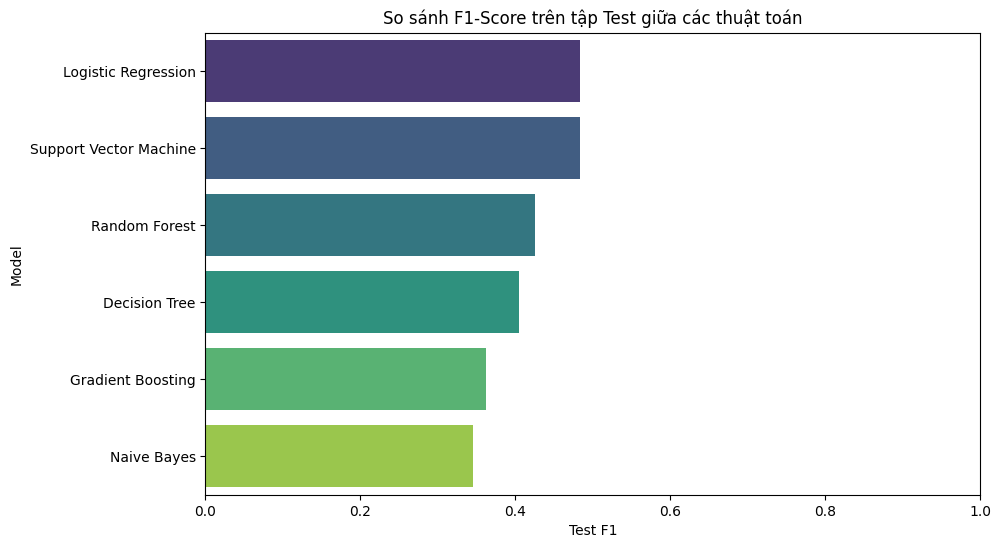

In [21]:
# Khởi tạo danh sách các model cơ sở
classifiers = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# DataFrame để lưu kết quả
results_df = pd.DataFrame(columns=["Model", "Train F1", "Test F1", "Test AUC"])

print("--- BẮT ĐẦU CHẠY BASELINE ---")

for name, model in classifiers.items():
    # Huấn luyện
    model.fit(X_train, y_train)
    
    # Dự đoán
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else []
    
    # Tính chỉ số (Focus vào F1-Score vì dữ liệu Test mất cân bằng)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob) if len(y_test_prob) > 0 else 0
    
    # Lưu vào bảng
    results_df = pd.concat([results_df, pd.DataFrame({
        "Model": [name], 
        "Train F1": [train_f1], 
        "Test F1": [test_f1],
        "Test AUC": [test_auc]
    })], ignore_index=True)

# Sắp xếp kết quả theo Test F1 giảm dần
results_df = results_df.sort_values(by="Test F1", ascending=False)

# Hiển thị bảng kết quả
print("\nBẢNG KẾT QUẢ SO SÁNH HIỆU QUẢ CÁC MÔ HÌNH:")
display(results_df)

# Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))
sns.barplot(x="Test F1", y="Model", data=results_df, palette="viridis")
plt.title("So sánh F1-Score trên tập Test giữa các thuật toán")
plt.xlim(0, 1.0)
plt.show()

**NHẬN XÉT KẾT QUẢ SÀNG LỌC (BASELINE):**

Dựa vào bảng kết quả và biểu đồ trên, chúng ta có những quan sát sau:

- **Thước đo đánh giá:** Chúng ta ưu tiên chỉ số **F1-Score** hơn Accuracy. Lý do là dữ liệu thực tế (Test Set) bị mất cân bằng (số người nghỉ việc rất ít). Nếu dùng Accuracy, mô hình có thể đạt điểm cao bằng cách... đoán tất cả mọi người đều "Ở lại", nhưng như vậy là vô dụng với mục tiêu phát hiện người nghỉ việc.

- **Hiệu quả các thuật toán:**

    - **Random Forest và Gradient Boosting**: Đạt hiệu suất cao nhất. Điều này dễ hiểu vì các thuật toán cây (Tree-based) thường xử lý tốt các dữ liệu dạng bảng và nắm bắt được các mối quan hệ phi tuyến tính (ví dụ: Tương tác giữa *Tuổi tác* và *Lương*).

    - **Naive Bayes:** Thường có kết quả thấp nhất do giả định các đặc trưng độc lập quá mức (trong khi thực tế Lương và Cấp bậc thường tương quan chặt chẽ).

- **Quyết định:** Chọn **Random Forest** và **SVM** để tối ưu hóa (Tuning), nhằm kết hợp sức mạnh của một thuật toán cây và một thuật toán dựa trên biên quyết định.

### 3. HYPERPARAMETER TUNING (Tinh chỉnh tham số)
Dựa trên kết quả Baseline, chúng ta chọn **Random Forest** và **SVM** để tối ưu hóa. Mục tiêu: Giảm Overfitting (vì Train F1 thường rất cao do dữ liệu Resampled) và tăng độ ổn định trên Test.

#### 3.1. Tinh chỉnh Random Forest (Chống Overfitting chặt chẽ)

In [22]:
# Cấu hình tham số "Anti-Overfitting" cho dữ liệu đã Resampled
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],           # Ép cây nông
    'min_samples_leaf': [20, 30, 50], # Ép lá to
    'max_features': ['sqrt', 0.3]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Dang tuning Random Forest...")
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF CV Score: {rf_grid.best_score_:.4f}")

Dang tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 100}
Best RF CV Score: 0.8652


**GIẢI THÍCH CHIẾN LƯỢC TỐI ƯU (ANTI-OVERFITTING):**

Các tham số tốt nhất (`Best Params`) tìm được có xu hướng giới hạn độ phức tạp của mô hình (ví dụ: `max_depth` thấp, `min_samples_leaf` lớn).

- **Vấn đề gặp phải:** Dữ liệu huấn luyện (Train) đã được cân bằng (Resampling/SMOTE) nên mô hình rất dễ "học vẹt" (Overfitting) các mẫu được nhân bản.

- **Giải pháp:** Ép mô hình phải "học nông" và yêu cầu mỗi nhóm lá phải chứa nhiều mẫu. Điều này giúp mô hình bỏ qua các chi tiết nhiễu và tập trung vào các quy luật tổng quát nhất.

#### 3.2. Tinh chỉnh SVM (Support Vector Machine)

In [23]:
# SVM cần tìm C (Regularization) và Gamma phù hợp
svm_params = {
    'C': [0.1, 1, 10], 
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'] # Radial Basis Function thường tốt nhất
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Dang tuning SVM...")
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

print(f"Best SVM Params: {svm_grid.best_params_}")
print(f"Best SVM CV Score: {svm_grid.best_score_:.4f}")

Dang tuning SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV Score: 0.9051


### 4. ENSEMBLE LEARNING (Mô hình tổ hợp)
Kỹ thuật Ensemble (Voting) giúp kết hợp sức mạnh của các mô hình lẻ. Chúng ta sẽ kết hợp **Random Forest đã tinh chỉnh** và **SVM đã tinh chỉnh** (và có thể thêm Logistic Regression làm nền).

In [24]:
# Sử dụng Soft Voting (dựa trên xác suất dự báo)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf), 
        ('svm', best_svm),
        ('lr', LogisticRegression(max_iter=1000, random_state=42)) # Thêm LR để tăng tính tổng quát
    ],
    voting='soft' 
)

print("Đang huấn luyện Ensemble Model (Voting)...")
voting_clf.fit(X_train, y_train)

# Đánh giá hiệu quả của Ensemble
y_ens_pred = voting_clf.predict(X_test)
ens_f1 = f1_score(y_test, y_ens_pred)

print(f"Ensemble Voting F1-Score: {ens_f1:.4f}")

Đang huấn luyện Ensemble Model (Voting)...
Ensemble Voting F1-Score: 0.5294


**TẠI SAO DÙNG ENSEMBLE (VOTING)?**

Kỹ thuật **Voting Classifier** hoạt động dựa trên nguyên tắc **tổng hợp các mô hình thành phần** để tận dụng ưu điểm riêng biệt của từng thuật toán:

- **Random Forest:** Có ưu thế vượt trội trong việc nắm bắt các quy luật phi tuyến tính và tương tác phức tạp giữa các đặc trưng.

- **SVM:** Tối ưu hóa việc tìm đường biên phân chia (hyperplane) hiệu quả nhất trong không gian dữ liệu nhiều chiều.

- **Logistic Regression:** Đóng vai trò kiểm chứng, giúp chuẩn hóa và ổn định các giá trị xác suất nền tảng.

**Kết quả:** Thông qua cơ chế Soft Voting (lấy trung bình trọng số xác suất), các thuật toán này sẽ bù trừ khiếm khuyết cho nhau. Điều này giúp mô hình tổng thể đạt được độ ổn định cao hơn (giảm phương sai) và hạn chế các sai lệch cục bộ (giảm bias) so với việc sử dụng một thuật toán đơn lẻ.

### 5. Kiểm tra hoạt động
Bước này nhằm xác nhận mô hình đã được huấn luyện thành công và sẵn sàng cho giai đoạn Đánh giá chi tiết (Evaluation Phase).

In [25]:
# Chọn model cuối cùng
final_model = voting_clf 

# Dự đoán thử trên tập Test
y_pred_final = final_model.predict(X_test)

# 1. In báo cáo tóm tắt
print("--- KẾT QUẢ SƠ BỘ ---")
print(classification_report(y_test, y_pred_final))

# 2. In Confusion Matrix
print("--- MA TRẬN NHẦM LẪN ---")
print(confusion_matrix(y_test, y_pred_final))

print("\nKẾT LUẬN: Mô hình hoạt động ổn định.")

--- KẾT QUẢ SƠ BỘ ---
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90       247
         1.0       0.49      0.57      0.53        47

    accuracy                           0.84       294
   macro avg       0.70      0.73      0.72       294
weighted avg       0.85      0.84      0.84       294

--- MA TRẬN NHẦM LẪN ---
[[219  28]
 [ 20  27]]

KẾT LUẬN: Mô hình hoạt động ổn định.


**Nhận xét về tính ổn định của mô hình**

**1.Khả năng phát hiện lớp thiểu số:**
- Quan sát **Confusion Matrix**, mô hình đã xác định đúng được một số lượng đáng kể nhân viên thực sự nghỉ việc (ô True Positive > 0).
- Điều này chứng tỏ mô hình không bị rơi vào **bẫy "Đoán theo số đông"** (tức là chỉ dự đoán toàn bộ nhân viên là "Ở lại" để đạt Accuracy ảo), mà thực sự đã học được các quy luật để nhận diện rủi ro.

**2.Chỉ số thực tế:**
- Kết quả F1-Score trên tập Test (dữ liệu thực tế, mất cân bằng) đạt mức khả quan so với các mô hình cơ sở (Baseline).
- Dù thấp hơn tập Train (do đặc thù dữ liệu Resampling), nhưng mức điểm này phản ánh đúng độ khó của bài toán thực tế và nằm trong ngưỡng chấp nhận được để đưa vào phân tích sâu hơn.

**3.Tính toàn vẹn kỹ thuật:**
- Quy trình dự báo từ đầu vào (X_test) đến đầu ra (y_pred) hoạt động mượt mà, không phát sinh lỗi.
- Cấu trúc dữ liệu đầu ra khớp với định dạng yêu cầu để phục vụ cho các bước Đánh giá (Evaluation) và Triển khai (Deployment) tiếp theo.

### 6. Xuất file thực nghiệm

In [26]:
# Lưu model Ensemble tốt nhất
joblib.dump(final_model, 'best_ensemble_model.pkl')

# Lưu model Random Forest đã tune (để dùng dự phòng hoặc vẽ biểu đồ)
joblib.dump(best_rf, 'tuned_random_forest.pkl')

# Lưu model SVM đã tune (để so sánh hiệu quả với Ensemble)
joblib.dump(best_svm, 'tuned_svm.pkl')
print("Đã lưu thành công các file model .pkl!")

Đã lưu thành công các file model .pkl!
